# Esse algoritmo atua nas analises na região do cariri

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Localiza onde o Scripts está e sobe um nível para a raiz do projeto (se o arquivo estiver renomeado, ele localiza onde estamos basicmamnte)

# Path.cwd() é a pasta 'Scripts', o .parent vai para 'analise_bnb'
RAIZ_PROJETO = Path.cwd().parent

# Define o caminho para a pasta de dados filtrados
PASTA_FILTRADOS = RAIZ_PROJETO / 'Dados_filtrados'

In [ ]:
#Definindo os dataframes  em questão
df_2022 = pd.read_csv(PASTA_FILTRADOS / '2022' / 'anual_2022_cariri.csv', sep =',' , encoding='utf-8')
df_2023 = pd.read_csv(PASTA_FILTRADOS / '2023' / 'anual_2023_cariri.csv', sep =',' , encoding='utf-8')
df_2024 = pd.read_csv(PASTA_FILTRADOS / '2024' / 'anual_2024_cariri.csv', sep =',' , encoding='utf-8')
df_2025 = pd.read_csv(PASTA_FILTRADOS / '2025' / 'anual_2025_cariri.csv', sep =',' , encoding='utf-8')




C:\Users\wesle\AppData\Local\Temp\ipykernel_16456\3524301665.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_completo['DT_MOV'] = pd.to_datetime(df_completo['DT_MOV'], dayfirst=True, errors='coerce')


# Quantidade de contratos por ano, maior valor de contrato e menor valor de contrato 2022


In [3]:
def calcular_valores_contratos(df, ano):
    valor_contrato_total = df['VALOR_CTR'].sum()
    valor_contrato_maior = df['VALOR_CTR'].max()
    valor_contrato_menor = df['VALOR_CTR'].min()
    
    print(f'Valor total dos contratos em {ano}: {valor_contrato_total} \n')
    print(f'Maior valor de contratos em {ano}: {valor_contrato_maior} \n')
    print(f'Menor valor de contratos em {ano}: {valor_contrato_menor} \n')
    print('---' * 20)

def contratos_por_ano(df, ano):
    contratos_total_ano = df['QTD'].sum()
    print(f'Quantidade de contratos em {ano}: {contratos_total_ano} \n')

contratos_por_ano(df_2022, 2022)
calcular_valores_contratos(df_2022, 2022)
contratos_por_ano(df_2023, 2023)
calcular_valores_contratos(df_2023, 2023)
contratos_por_ano(df_2024, 2024)
calcular_valores_contratos(df_2024, 2024)
contratos_por_ano(df_2025, 2025)
calcular_valores_contratos(df_2025, 2025)

Quantidade de contratos em 2022: 12401.0 

Valor total dos contratos em 2022: 93535658.93 

Maior valor de contratos em 2022: 404244.81 

Menor valor de contratos em 2022: 989.5 

------------------------------------------------------------
Quantidade de contratos em 2023: 11857.0 

Valor total dos contratos em 2023: 131952033.33 

Maior valor de contratos em 2023: 579800.0 

Menor valor de contratos em 2023: 2000.0 

------------------------------------------------------------
Quantidade de contratos em 2024: 12517.0 

Valor total dos contratos em 2024: 168208775.89 

Maior valor de contratos em 2024: 784000.0 

Menor valor de contratos em 2024: 1000.0 

------------------------------------------------------------
Quantidade de contratos em 2025: 13724.0 

Valor total dos contratos em 2025: 199465454.0 

Maior valor de contratos em 2025: 768456.19 

Menor valor de contratos em 2025: 150.0 

------------------------------------------------------------


# Quais produtos tem mais demanda de contratos? E quais tem menos demanda? Maior e menor aporte financeiro (2022) 

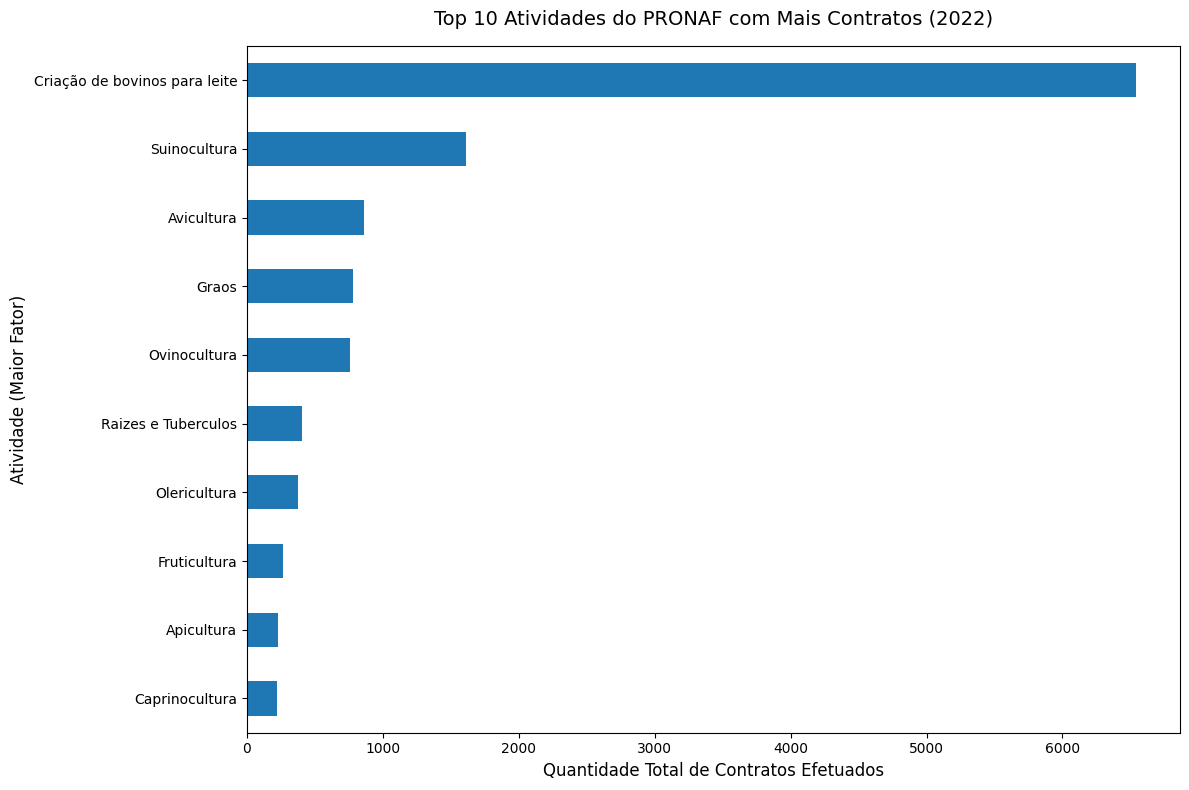

In [4]:
#Agrupa por Atividade e SOMA a quantidade de contratos (Coluna QTD)
atividades_reais = df_2022.groupby('ATIVIDADE(maior fator)')['QTD'].sum()

# Pega apenas as 10 maiores atividades para limpar o gráfico
top_10_atividades = atividades_reais.nlargest(10).sort_values(ascending=True)

# Plota o gráfico
top_10_atividades.plot(kind='barh', figsize=(12, 8))

# Customização
plt.title('Top 10 Atividades do PRONAF com Mais Contratos (2022)', fontsize=14, pad=15)
plt.xlabel('Quantidade Total de Contratos Efetuados', fontsize=12)
plt.ylabel('Atividade (Maior Fator)', fontsize=12)

plt.tight_layout()
plt.show()

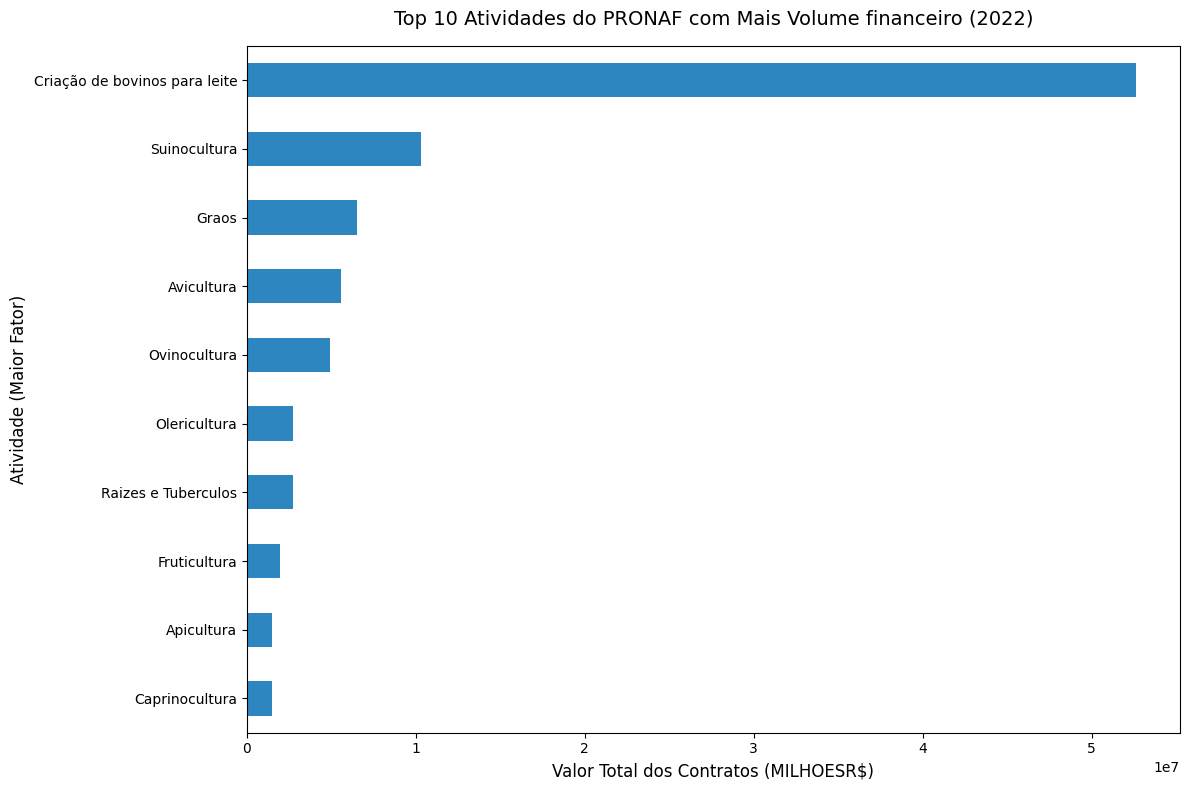

In [5]:
atividades_reais = df_2022.groupby('ATIVIDADE(maior fator)')['VALOR_CTR'].sum()

top_10_atividades = atividades_reais.nlargest(10).sort_values(ascending=True)

top_10_atividades.plot(kind='barh', figsize=(12, 8), color='#2E86C1')

plt.title('Top 10 Atividades do PRONAF com Mais Volume financeiro (2022)', fontsize=14, pad=15)
plt.xlabel('Valor Total dos Contratos (MILHOESR$)', fontsize=12)
plt.ylabel('Atividade (Maior Fator)', fontsize=12)
plt.tight_layout()
plt.show()

Aporte financeiro para Criação de bovinos para leite: R$ 52.602.597,68 

Aporte financeiro para Suinocultura: R$ 10.291.723,01

# Pronaf e seus subprogramas nisso tudo (2022)

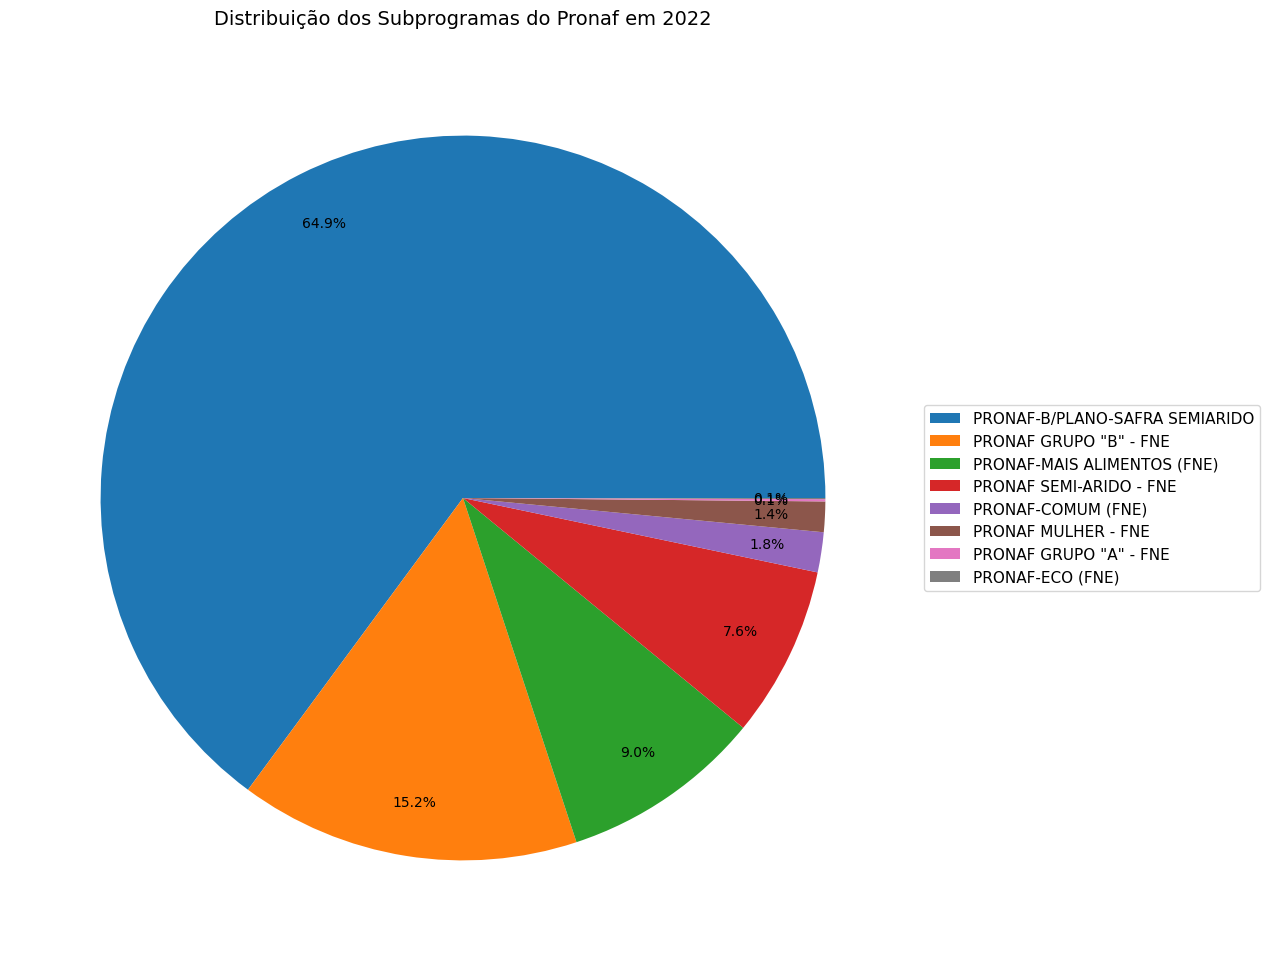

In [6]:
# Armazenamos a contagem para usar na legenda
contagem_programa = df_2022['PROGRAMA'].value_counts()

# Plotamos a pizza SEM os rótulos de texto nas fatias (labels=None)
contagem_programa.plot(
    kind='pie', 
    autopct='%1.1f%%', 
    labels=None,          # Remove o texto de cima da fatia
    pctdistance=0.85,     # Afasta as porcentagens do centro para não embolar
    figsize=(12, 10), 
    fontsize=10
)

plt.legend(
    labels=contagem_programa.index, 
    loc="center left", 
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=11
)

plt.title('Distribuição dos Subprogramas do Pronaf em 2022', fontsize=14, pad=15)
plt.ylabel('')
plt.tight_layout()
plt.show()

# Cidades com mais contratos

In [7]:
cidade_com_mais_contratos_no_ano = df_2022.groupby('NM_MUN')['QTD'].sum()
top_10_cidades = cidade_com_mais_contratos_no_ano.nlargest(10).sort_values(ascending=False)
print(top_10_cidades)

NM_MUN
MAURITI                 1629.0
JARDIM                  1293.0
PORTEIRAS                839.0
LAVRAS DA MANGABEIRA     698.0
VARZEA ALEGRE            656.0
BREJO SANTO              622.0
ASSARE                   610.0
AURORA                   550.0
BARRO                    508.0
BARBALHA                 468.0
Name: QTD, dtype: float64


# Contratos a partir do genero (2022)

In [12]:
print('Quantidade de registros para GÊNERO em 2022 = F: {}'.format((df_2022['GÊNERO'] == 'F').sum()))
print('Quantidade de registros para GÊNERO em 2022 = M: {}'.format((df_2022['GÊNERO'] == 'M').sum()))


Quantidade de registros para GÊNERO em 2022 = F: 1867
Quantidade de registros para GÊNERO em 2022 = M: 2112


#                                                                                                                  2023

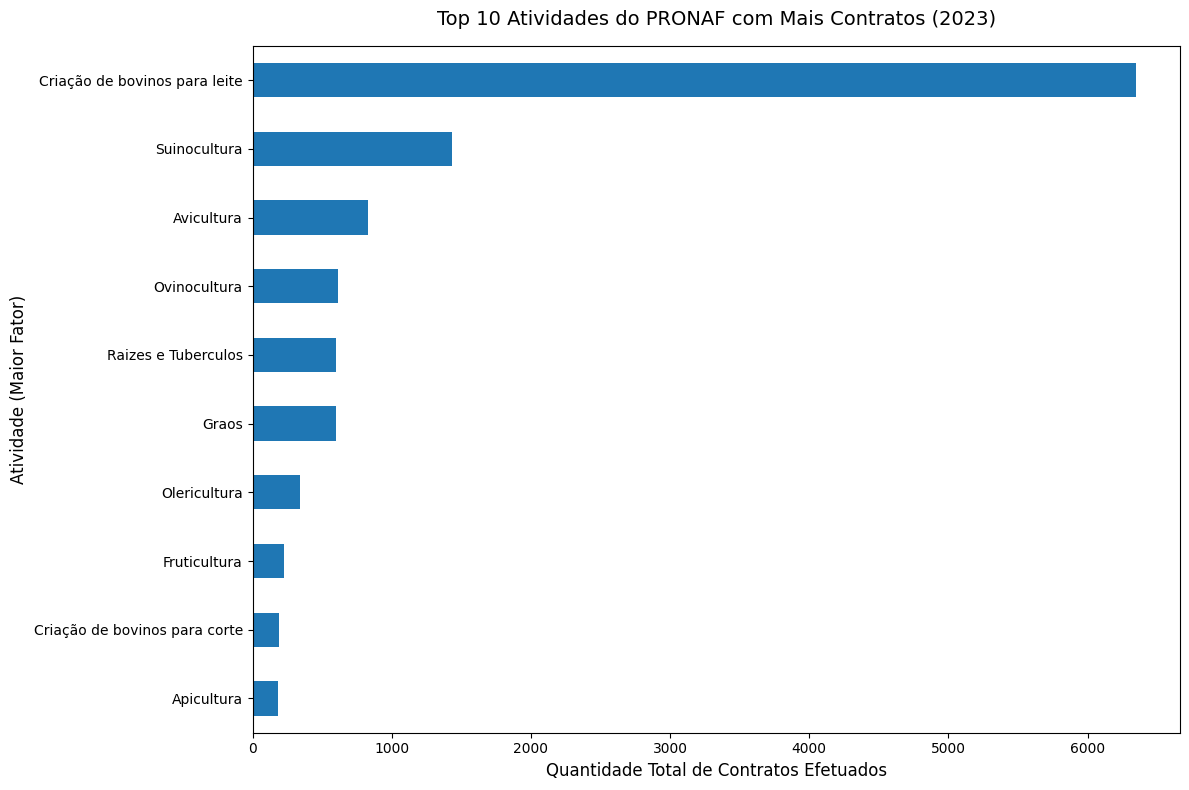

In [ ]:
#Agrupa por Atividade e SOMA a quantidade de contratos
atividades_reais = df_2023.groupby('ATIVIDADE(maior fator)')['QTD'].sum()

# Pega apenas as 10 maiores atividades para limpar o gráfico
top_10_atividades = atividades_reais.nlargest(10).sort_values(ascending=True)

# Plota o gráfico
top_10_atividades.plot(kind='barh', figsize=(12, 8))

# Customização
plt.title('Top 10 Atividades do PRONAF com Mais Contratos (2023)', fontsize=14, pad=15)
plt.xlabel('Quantidade Total de Contratos Efetuados', fontsize=12)
plt.ylabel('Atividade (Maior Fator)', fontsize=12)

plt.tight_layout()
plt.show()

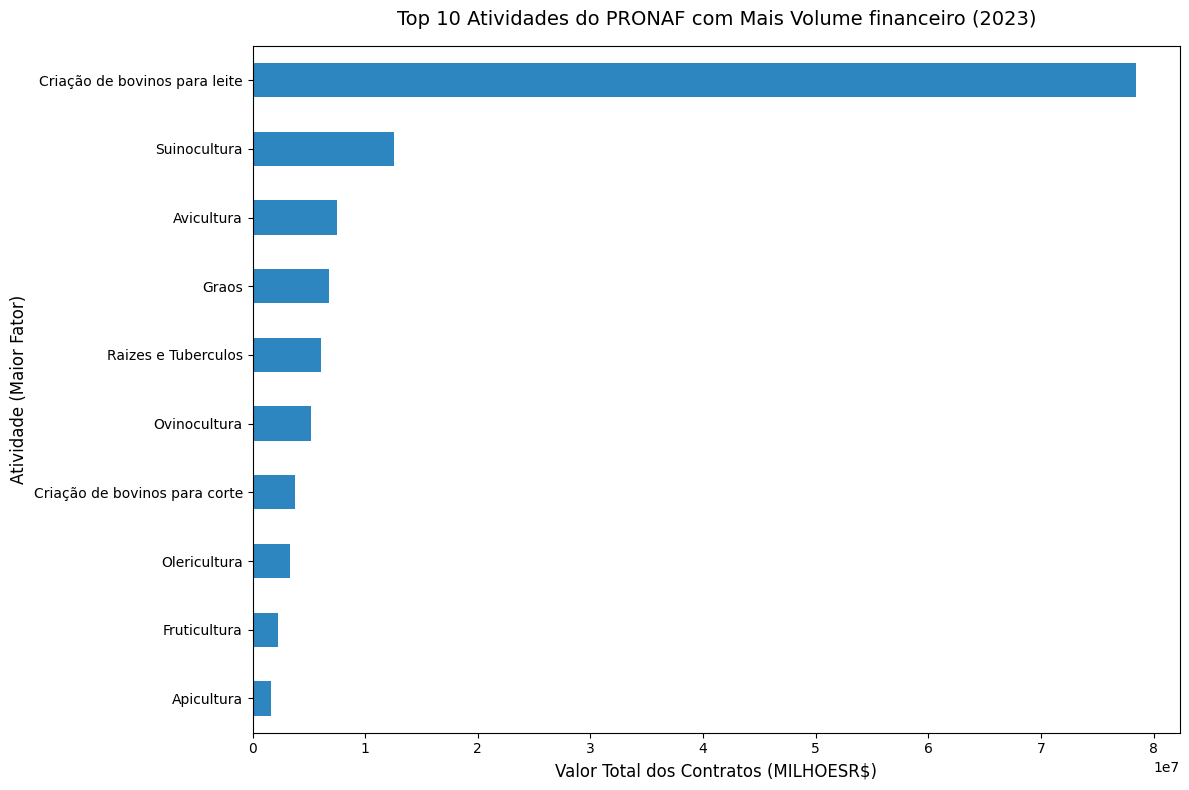

In [ ]:
atividades_reais = df_2023.groupby('ATIVIDADE(maior fator)')['VALOR_CTR'].sum()

top_10_atividades = atividades_reais.nlargest(10).sort_values(ascending=True)

top_10_atividades.plot(kind='barh', figsize=(12, 8), color='#2E86C1')

plt.title('Top 10 Atividades do PRONAF com Mais Volume financeiro (2023)', fontsize=14, pad=15)
plt.xlabel('Valor Total dos Contratos (MILHOESR$)', fontsize=12)
plt.ylabel('Atividade (Maior Fator)', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
cidade_com_mais_contratos_no_ano = df_2023.groupby('NM_MUN')['QTD'].sum()
top_10_cidades = cidade_com_mais_contratos_no_ano.nlargest(10).sort_values(ascending=False)
print(top_10_cidades)

NM_MUN
MAURITI                 1730.0
JARDIM                  1183.0
VARZEA ALEGRE            698.0
PORTEIRAS                637.0
LAVRAS DA MANGABEIRA     594.0
ASSARE                   590.0
SALITRE                  547.0
BARRO                    538.0
AURORA                   498.0
CARIRIACU                484.0
Name: QTD, dtype: float64


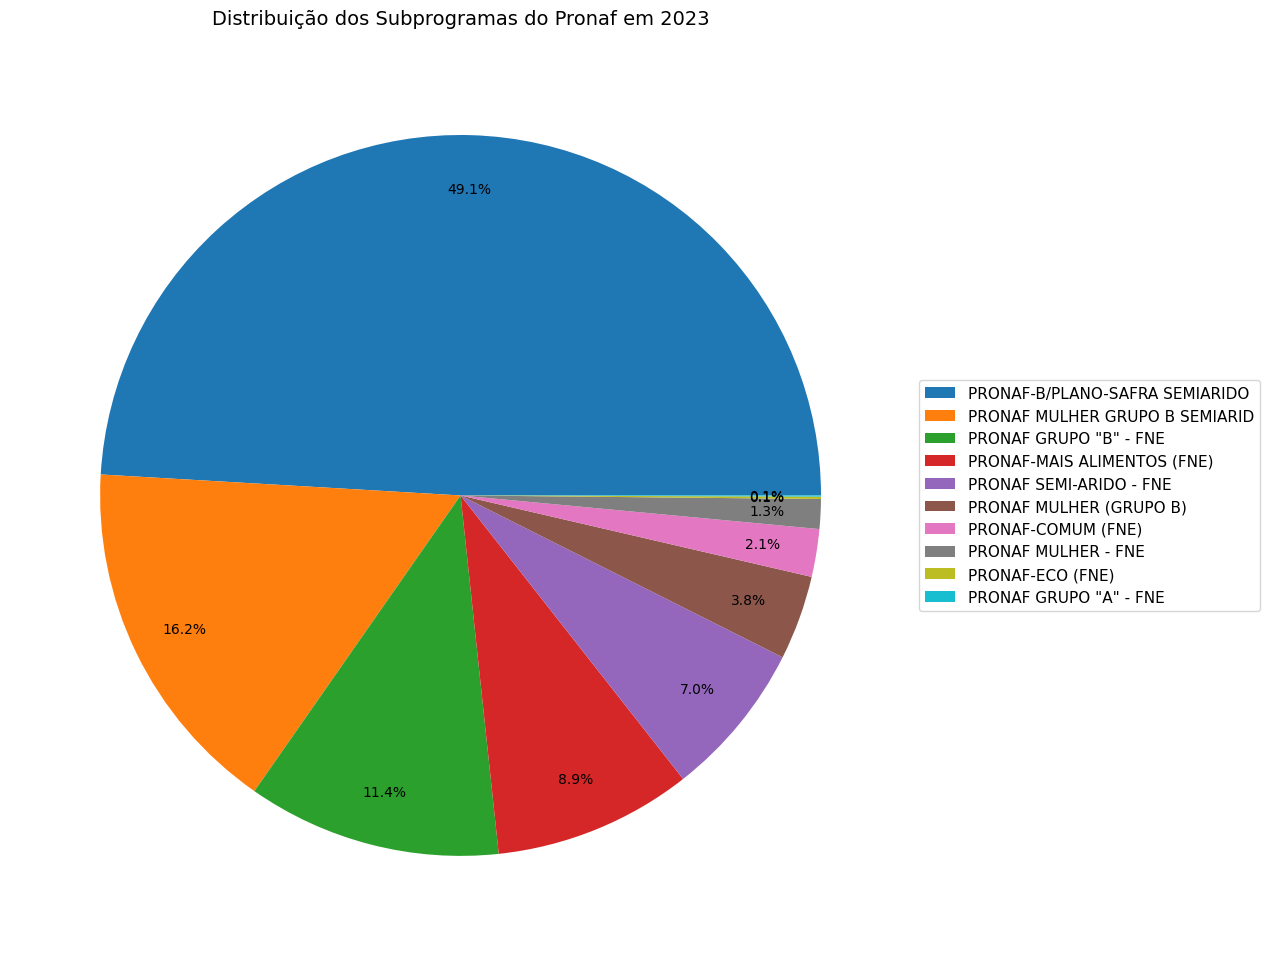

In [ ]:
# Armazenamos a contagem para usar na legenda
contagem_programa = df_2023['PROGRAMA'].value_counts()

# Plotamos a pizza SEM os rótulos de texto nas fatias (labels=None)
contagem_programa.plot(
    kind='pie', 
    autopct='%1.1f%%', 
    labels=None,          # Remove o texto de cima da fatia
    pctdistance=0.85,     # Afasta as porcentagens do centro para não embolar
    figsize=(12, 10), 
    fontsize=10
)

plt.legend(
    labels=contagem_programa.index, 
    loc="center left", 
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=11
)

plt.title('Distribuição dos Subprogramas do Pronaf em 2023', fontsize=14, pad=15)
plt.ylabel('')
plt.tight_layout()
plt.show()

# 2024

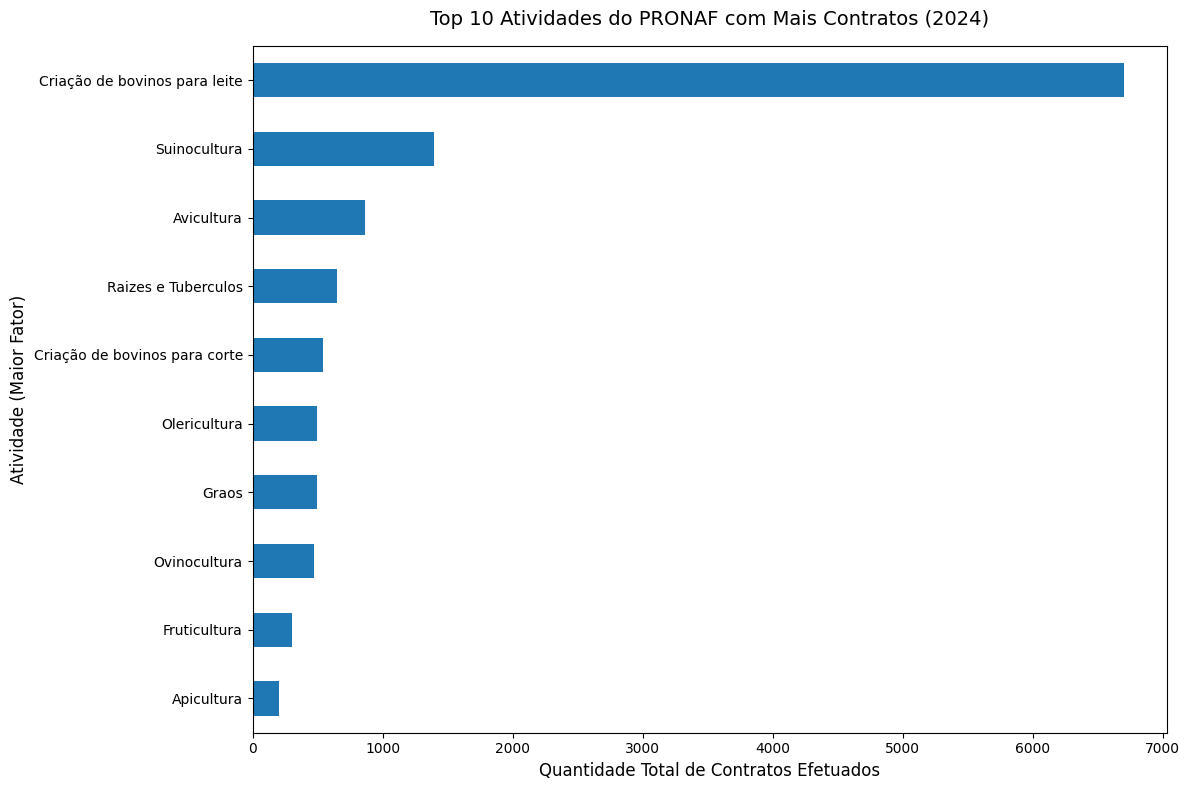

In [ ]:
#Agrupa por Atividade e SOMA a quantidade de contratos
atividades_reais = df_2024.groupby('ATIVIDADE(maior fator)')['QTD'].sum()

# Pega apenas as 10 maiores atividades para limpar o gráfico
top_10_atividades = atividades_reais.nlargest(10).sort_values(ascending=True)

# Plota o gráfico
top_10_atividades.plot(kind='barh', figsize=(12, 8))

# Customização
plt.title('Top 10 Atividades do PRONAF com Mais Contratos (2024)', fontsize=14, pad=15)
plt.xlabel('Quantidade Total de Contratos Efetuados', fontsize=12)
plt.ylabel('Atividade (Maior Fator)', fontsize=12)

plt.tight_layout()
plt.show()

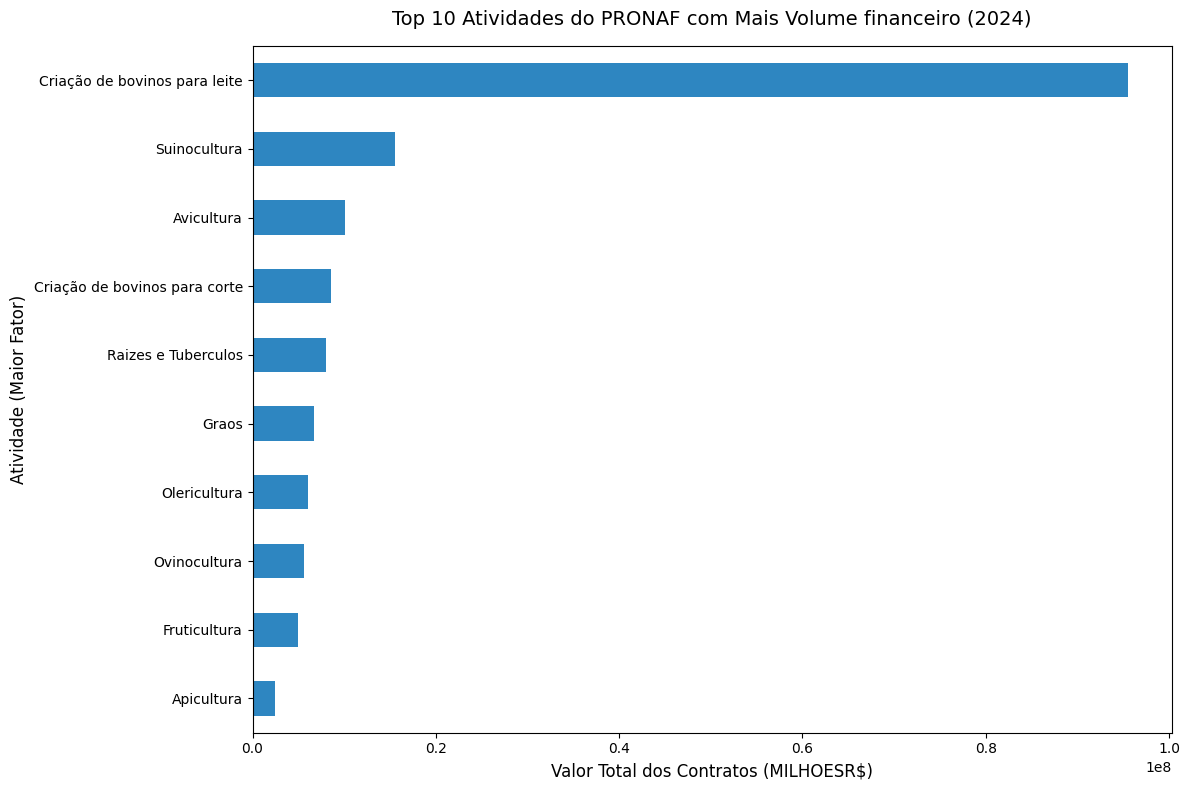

In [ ]:
atividades_reais = df_2024.groupby('ATIVIDADE(maior fator)')['VALOR_CTR'].sum()

top_10_atividades = atividades_reais.nlargest(10).sort_values(ascending=True)

top_10_atividades.plot(kind='barh', figsize=(12, 8), color='#2E86C1')

plt.title('Top 10 Atividades do PRONAF com Mais Volume financeiro (2024)', fontsize=14, pad=15)
plt.xlabel('Valor Total dos Contratos (MILHOESR$)', fontsize=12)
plt.ylabel('Atividade (Maior Fator)', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
cidade_com_mais_contratos_no_ano = df_2024.groupby('NM_MUN')['QTD'].sum()
top_10_cidades = cidade_com_mais_contratos_no_ano.nlargest(10).sort_values(ascending=False)
print(top_10_cidades)

NM_MUN
MAURITI                 1785.0
JARDIM                  1367.0
LAVRAS DA MANGABEIRA     869.0
PORTEIRAS                764.0
VARZEA ALEGRE            719.0
AURORA                   659.0
ASSARE                   622.0
BREJO SANTO              550.0
SALITRE                  532.0
BARRO                    521.0
Name: QTD, dtype: float64


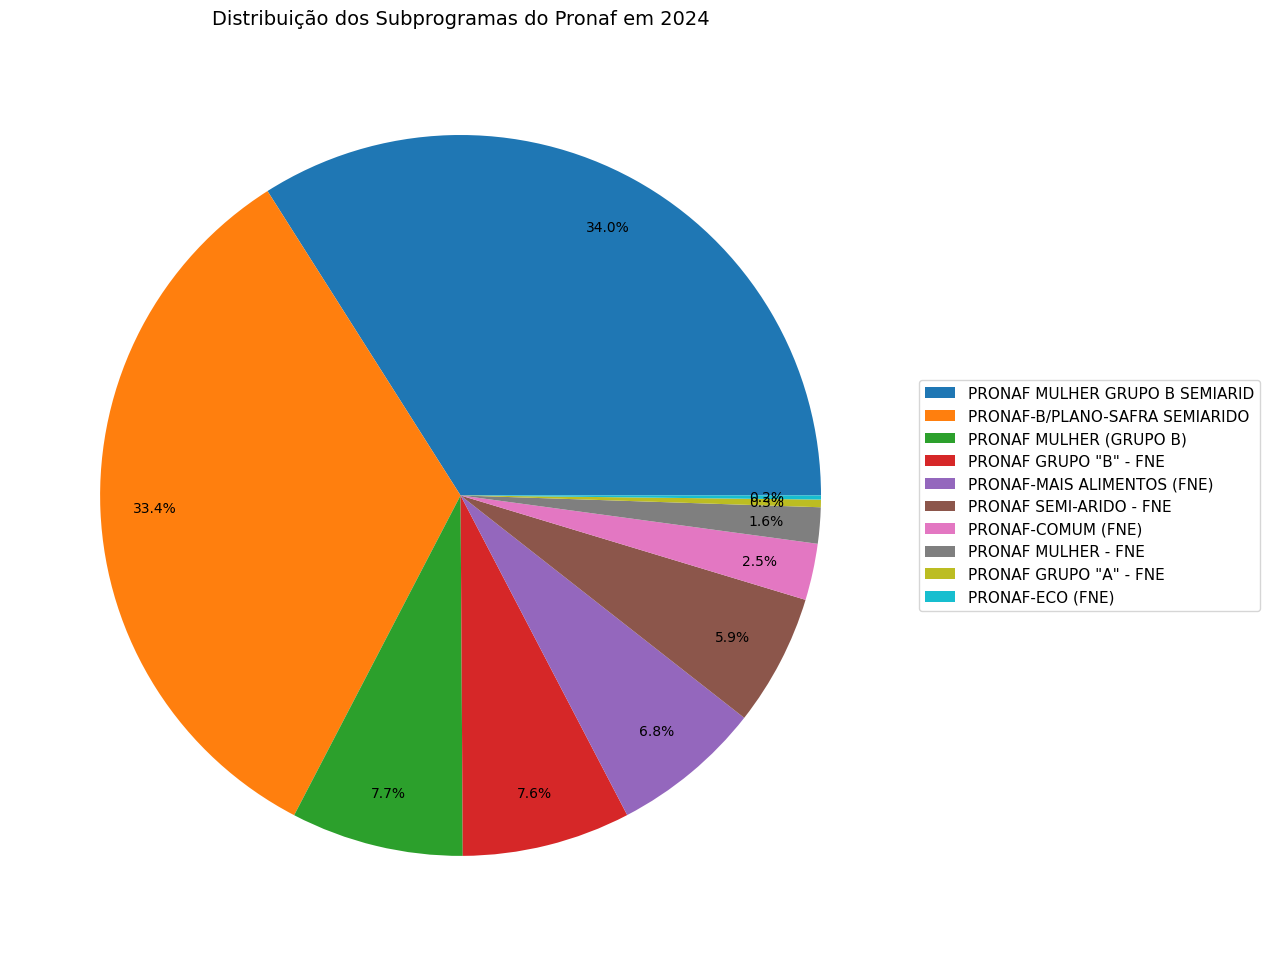

In [ ]:
# Armazenamos a contagem para usar na legenda
contagem_programa = df_2024['PROGRAMA'].value_counts()

# Plotamos a pizza SEM os rótulos de texto nas fatias (labels=None)
contagem_programa.plot(
    kind='pie', 
    autopct='%1.1f%%', 
    labels=None,          # Remove o texto de cima da fatia
    pctdistance=0.85,     # Afasta as porcentagens do centro para não embolar
    figsize=(12, 10), 
    fontsize=10
)

plt.legend(
    labels=contagem_programa.index, 
    loc="center left", 
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=11
)

plt.title('Distribuição dos Subprogramas do Pronaf em 2024', fontsize=14, pad=15)
plt.ylabel('')
plt.tight_layout()
plt.show()

# 2025

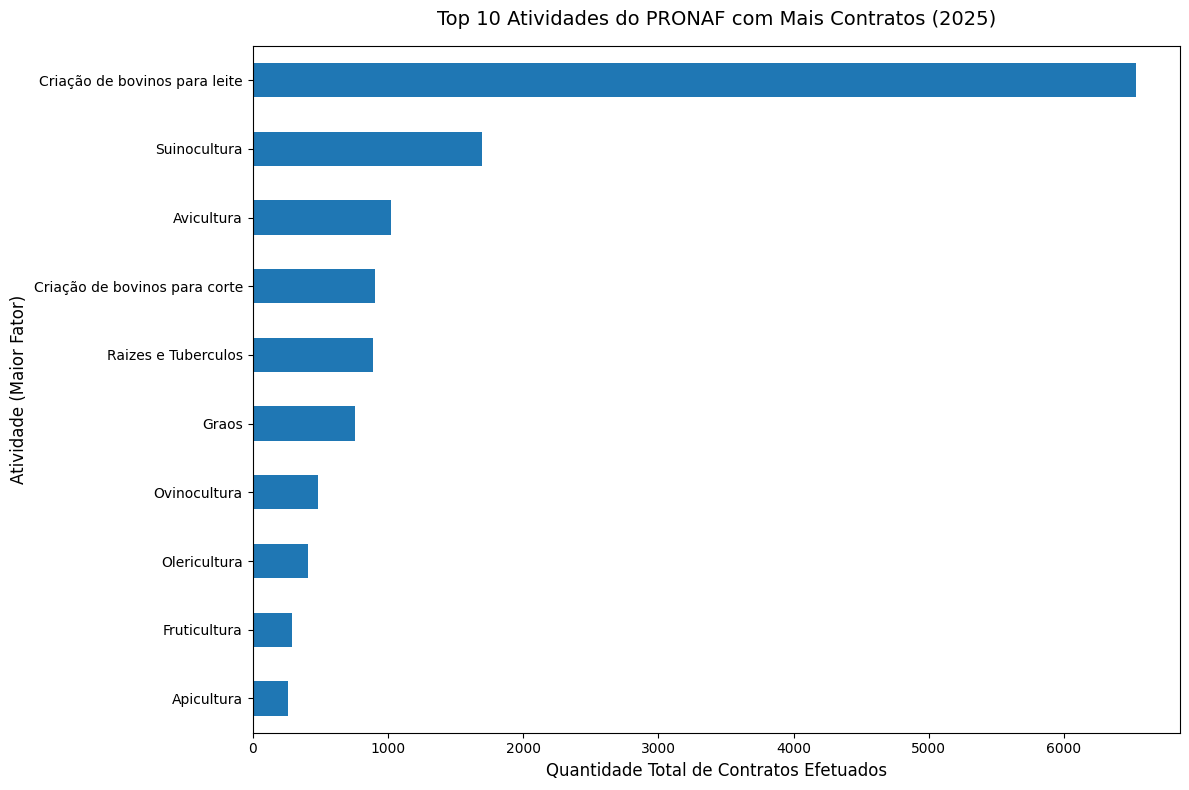

In [ ]:
#Agrupa por Atividade e SOMA a quantidade de contratos
atividades_reais = df_2025.groupby('ATIVIDADE(maior fator)')['QTD'].sum()

# Pega apenas as 10 maiores atividades para limpar o gráfico
top_10_atividades = atividades_reais.nlargest(10).sort_values(ascending=True)

# Plota o gráfico
top_10_atividades.plot(kind='barh', figsize=(12, 8))

# Customização
plt.title('Top 10 Atividades do PRONAF com Mais Contratos (2025)', fontsize=14, pad=15)
plt.xlabel('Quantidade Total de Contratos Efetuados', fontsize=12)
plt.ylabel('Atividade (Maior Fator)', fontsize=12)

plt.tight_layout()
plt.show()

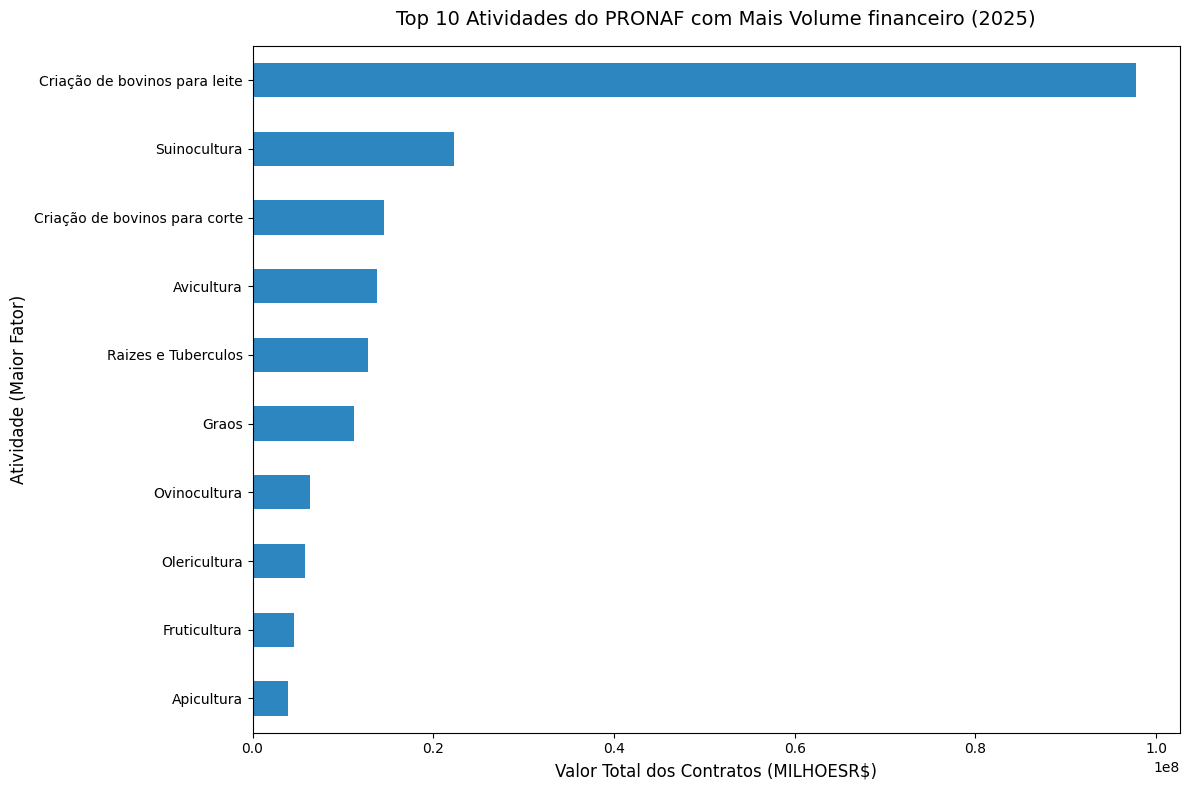

In [ ]:
atividades_reais = df_2025.groupby('ATIVIDADE(maior fator)')['VALOR_CTR'].sum()

top_10_atividades = atividades_reais.nlargest(10).sort_values(ascending=True)

top_10_atividades.plot(kind='barh', figsize=(12, 8), color='#2E86C1')

plt.title('Top 10 Atividades do PRONAF com Mais Volume financeiro (2025)', fontsize=14, pad=15)
plt.xlabel('Valor Total dos Contratos (MILHOESR$)', fontsize=12)
plt.ylabel('Atividade (Maior Fator)', fontsize=12)
plt.tight_layout()
plt.show()

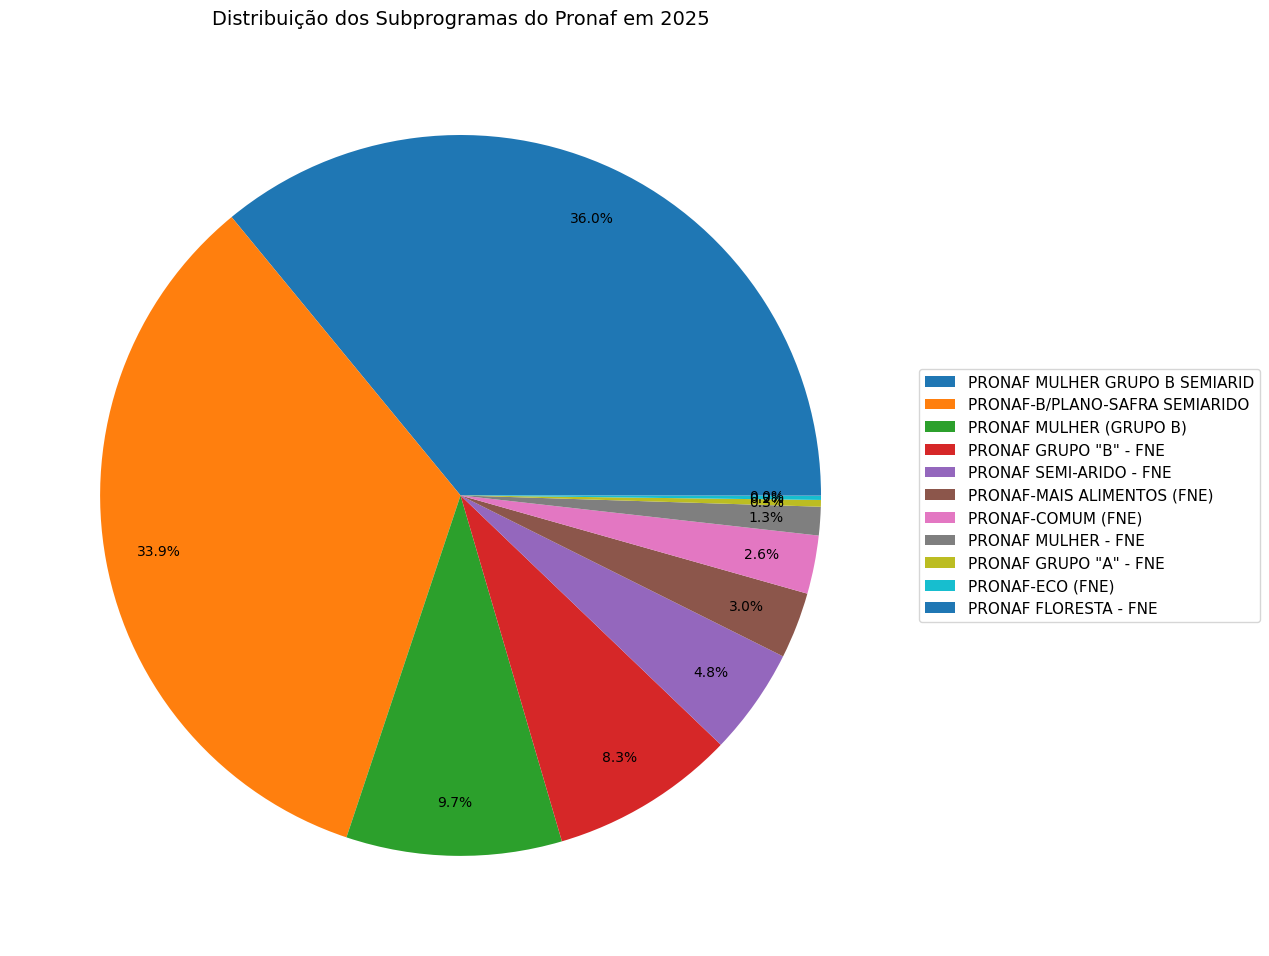

In [ ]:
# Armazenamos a contagem para usar na legenda
contagem_programa = df_2025['PROGRAMA'].value_counts()

# Plotamos a pizza SEM os rótulos de texto nas fatias (labels=None)
contagem_programa.plot(
    kind='pie', 
    autopct='%1.1f%%', 
    labels=None,          # Remove o texto de cima da fatia
    pctdistance=0.85,     # Afasta as porcentagens do centro para não embolar
    figsize=(12, 10), 
    fontsize=10
)

plt.legend(
    labels=contagem_programa.index, 
    loc="center left", 
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=11
)

plt.title('Distribuição dos Subprogramas do Pronaf em 2025', fontsize=14, pad=15)
plt.ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
cidade_com_mais_contratos_no_ano = df_2025.groupby('NM_MUN')['QTD'].sum()
top_10_cidades = cidade_com_mais_contratos_no_ano.nlargest(10).sort_values(ascending=False)
print(top_10_cidades)

NM_MUN
MAURITI                 1703.0
JARDIM                  1256.0
LAVRAS DA MANGABEIRA    1046.0
VARZEA ALEGRE            917.0
PORTEIRAS                779.0
SALITRE                  719.0
MILAGRES                 603.0
AURORA                   602.0
BREJO SANTO              590.0
ASSARE                   525.0
Name: QTD, dtype: float64


# Custeio x Investimento Rural 

In [34]:
# 1. Agrupamos os seus DataFrames e os respetivos anos numa lista
dados_anuais = [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024),
    (2025, df_2025)
]

# 2. Aplicamos exatamente a sua lógica de contagem para cada ano
for ano, df_ano in dados_anuais:
    qtd_investimento = (df_ano['FINALIDADE'] == 'INVESTIMENTO RURAL').sum()
    qtd_custeio = (df_ano['FINALIDADE'] == 'CUSTEIO').sum()
    
    print(f'--- Evolução no ano de {ano} ---')
    print(f'Quantidade de registos para INVESTIMENTO RURAL: {qtd_investimento}')
    print(f'Quantidade de registos para CUSTEIO: {qtd_custeio}')
    print('-' * 40)

print('-' * 50)
print('-' * 50)
print('\n')
for ano, df_ano in dados_anuais:
    qtd_investimento = df_ano.loc[df_ano['FINALIDADE'] == 'INVESTIMENTO RURAL', 'VALOR_CTR'].sum()
    qtd_custeio = df_ano.loc[df_ano['FINALIDADE'] == 'CUSTEIO', 'VALOR_CTR'].sum()
    
    print(f'--- Evolução no ano de {ano} ---')
    print(f'Valor total para INVESTIMENTO RURAL: {qtd_investimento}')
    print(f'Valor total para CUSTEIO: {qtd_custeio}')
    print('-' * 40)


--- Evolução no ano de 2022 ---
Quantidade de registos para INVESTIMENTO RURAL: 3820
Quantidade de registos para CUSTEIO: 159
----------------------------------------
--- Evolução no ano de 2023 ---
Quantidade de registos para INVESTIMENTO RURAL: 3668
Quantidade de registos para CUSTEIO: 163
----------------------------------------
--- Evolução no ano de 2024 ---
Quantidade de registos para INVESTIMENTO RURAL: 3574
Quantidade de registos para CUSTEIO: 253
----------------------------------------
--- Evolução no ano de 2025 ---
Quantidade de registos para INVESTIMENTO RURAL: 4417
Quantidade de registos para CUSTEIO: 592
----------------------------------------
--------------------------------------------------
--------------------------------------------------


--- Evolução no ano de 2022 ---
Valor total para INVESTIMENTO RURAL: 90263553.16999999
Valor total para CUSTEIO: 3272105.76
----------------------------------------
--- Evolução no ano de 2023 ---
Valor total para INVESTIMENTO R

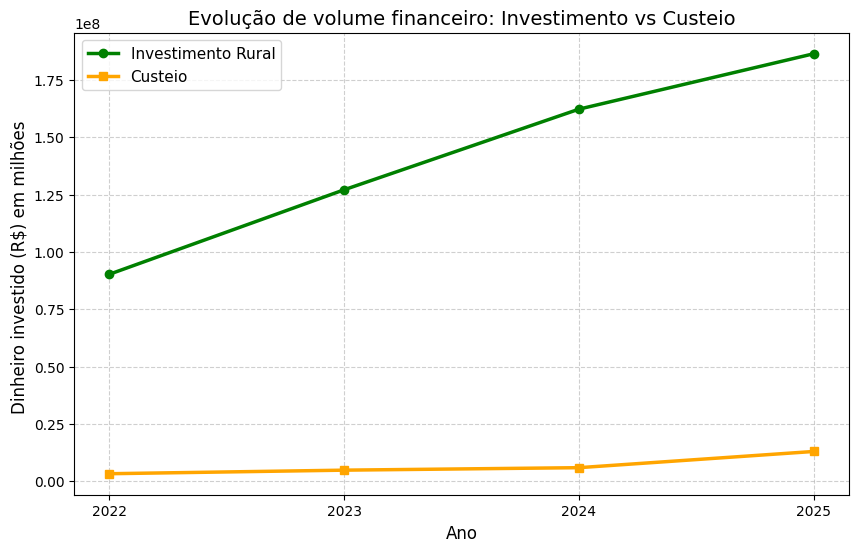

In [ ]:
dados_anuais = [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024),
    (2025, df_2025)
]

anos = []
investimentos = []
custeios = []

for ano, df_ano in dados_anuais:
    # 2. O 'Pulo do Gato': Usamos o .loc para filtrar a Finalidade e apontar qual coluna queremos somar (QTD)
    qtd_investimento = df_ano.loc[df_ano['FINALIDADE'] == 'INVESTIMENTO RURAL', 'VALOR_CTR'].sum()
    qtd_custeio = df_ano.loc[df_ano['FINALIDADE'] == 'CUSTEIO', 'VALOR_CTR'].sum()
    
    anos.append(ano)
    investimentos.append(qtd_investimento)
    custeios.append(qtd_custeio)

# teste_work = qtd_investimento.nlargest(10).sort_values(ascending=True)
# print(teste_work)


# Geração do Gráfico (Mesmo de antes)
plt.figure(figsize=(10, 6))

plt.plot(anos, investimentos, label='Investimento Rural', color='green', marker='o', linewidth=2.5)
plt.plot(anos, custeios, label='Custeio', color='orange', marker='s', linewidth=2.5)

plt.title('Investimento vs Custeio na região do cariri', fontsize=14)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Volume Financeiro (R$) em milhões ', fontsize=12)

plt.xticks(anos)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.show()

--- DIAGNÓSTICO DE VALORES (INVESTIMENTO RURAL) ---
Valor Médio do contrato: R$ 34,657.99
Valor Mediano (a exata metade dos produtores): R$ 17,000.00
O MAIOR contrato do ano inteiro: R$ 579,800.00

--- OS 5 MAIORES CONTRATOS DO ANO ---
 NM_MUN                       PRODUTO CATEGORIA              PORTE     VALOR_CTR
MAURITI Criação de bovinos para leite      MINI PRONAFIANO GRUPO B R$ 579,800.00
MAURITI Criação de bovinos para leite      MINI PRONAFIANO GRUPO B R$ 575,000.00
MAURITI Criação de bovinos para leite      MINI PRONAFIANO GRUPO B R$ 570,400.00
MAURITI Criação de bovinos para leite      MINI PRONAFIANO GRUPO B R$ 527,200.00
MAURITI Criação de bovinos para leite      MINI PRONAFIANO GRUPO B R$ 443,300.00


--- DISTRIBUIÇÃO DO DINHEIRO POR CATEGORIA (Em Milhões) ---
CATEGORIA
MINI    127.13
Name: VALOR_CTR, dtype: float64
